# SteamBank - Game Predictor and Analysis


## Problem Statement

- As an independent developer or a small studio, a game's overall performance in the competitive market depends on several key factors (i.e. Price, platform, languages, genre), and these factors are decided before release. However, such decisions are made often with little evidence to support the game's direction. Existing tools such as SteamDB can report what already happened to released games, but not how an unreleased game is likely to perform. The stakes are high, of all the paid games released on Steam before 2025, only 26.7% reached 20,000 owners. Most paid games never find a meaningful audience or the amount that can break even.

## Users

- For an indie developer, big and/or small studio, a poorly judged launch can waste months of work and most of its budget (i.e. Concord). This project aims to help developers by showing how unreleased games can compare with similar games on the market, and indicate which pre-launch decisions could improve its chances. 

In [1]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (7, 4.5)

## Data

- The [Steam Games Dataset from Kaggle](https://www.kaggle.com/datasets/fronkongames/steam-games-dataset/data): 125,855 games and 40 columns, with releases up to 25 December 2025, covering prices, genres, tags, store features, platforms, languages and estimated owners.

In [2]:
corrected_columns = [
    'AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price',
    'Discount', 'DLC count', 'About the game', 'Supported languages', 'Full audio languages',
    'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux',
    'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank',
    'Achievements', 'Recommendations', 'Notes', 'Average playtime forever',
    'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks',
    'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'
]

games = pd.read_csv('games.csv', low_memory=False, index_col=False, header=0, names=corrected_columns)
games_data = games.copy()
print(games_data.shape)


(125855, 40)


In [3]:
# First look at the raw data: column types, non-missing counts and summary statistics
games_data.info()
print(games_data.describe().round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125855 entries, 0 to 125854
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       125855 non-null  int64  
 1   Name                        125854 non-null  object 
 2   Release date                125855 non-null  object 
 3   Estimated owners            125855 non-null  object 
 4   Peak CCU                    125855 non-null  int64  
 5   Required age                125855 non-null  int64  
 6   Price                       125855 non-null  float64
 7   Discount                    125855 non-null  int64  
 8   DLC count                   125855 non-null  int64  
 9   About the game              117393 non-null  object 
 10  Supported languages         125855 non-null  object 
 11  Full audio languages        125855 non-null  object 
 12  Reviews                     12181 non-null   object 
 13  Header image  

## Missing Values

In [4]:
missing_val = games_data.isna().sum()
missing_val = missing_val[missing_val > 0].sort_values(ascending=False)
print((missing_val / len(games_data) * 100).round(1))

Movies            100.0
Score rank        100.0
Metacritic url     96.6
Reviews            90.3
Notes              81.5
Website            59.9
Support url        56.1
Tags               33.8
Support email      18.0
Categories          7.1
Publishers          7.1
About the game      6.7
Developers          6.7
Genres              6.7
Screenshots         4.8
Header image        0.1
Name                0.0
dtype: float64


- `Movies` and `Score rank` are 100% empty, and `Reviews` and `Metacritic url` are over 90% empty. None of these are used as features.
- `Tags` is missing for 33.8% of games, and `Genres` and `Categories` for about 7%. These are filled with an empty string, because a missing tag means the game has no tags, not that the row is broken, so the games are kept.
- The one game with no `Name` is dropped, along with rows whose owner estimate can't be read.

## Data Cleaning
- Cleaning:
  - Fixed the file's broken header (DiscountDLC count)
  - Removed unnamed games, 8,139 playtest builds and duplicate app IDs
  - Keeping paid games only
  - Keeping games only released before 2025 (games after 2025 did not have enough time to sell at the time the dataset was made for the model to predict clearly)
    
- Label: sold = 1 if a game's lower owner estimate is at least 20,000.

- Features: multi-hot genres and store features, the top 120 community tags (opinion tags excluded), and 7 numeric columns, with price and achievements log-scaled

- Leakage removed: reviews, playtime, DLC count and Steam Trading Cards, because each is only known after launch or depends on success.

In [5]:
games_data = games_data[games_data['Name'].notna()].copy()
games_data['Name'] = games_data['Name'].astype(str).str.strip()
games_data = games_data[games_data['Name'] != '']
games_data = games_data[~games_data['Name'].str.contains('playtest',case=False)]
games_data['AppID'] = pd.to_numeric(games_data['AppID'],errors='coerce')

print('Rows with a shared name:', games_data.duplicated(subset='Name', keep=False).sum())
print('Rows with repeated IDs:', games_data.duplicated(subset='AppID').sum())

games_data = games_data.drop_duplicates(subset='AppID', keep='first')

games_data['Genres'] = games_data['Genres'].fillna('')
games_data['Tags'] = games_data['Tags'].fillna('')
games_data['Categories'] = games_data['Categories'].fillna('')
games_data['Price'] = pd.to_numeric(games_data['Price'],errors='coerce').fillna(0)

games_data['owners_low'] = pd.to_numeric(games_data['Estimated owners'].astype(str).str.split(' - ').str[0],errors='coerce')
games_data = games_data[games_data['owners_low'].notna()].copy()

print(f"Games after cleaning: {games_data.shape[0]}")


Rows with a shared name: 2178
Rows with repeated IDs: 0
Games after cleaning: 117715


In [6]:
paid_game = games_data[games_data['Price'] > 0].copy()
paid_game['sold'] = (paid_game['owners_low'] >= 20000).astype(int)

print(f"Paid games: {paid_game.shape[0]}")
print(paid_game['sold'].value_counts(normalize=True).rename('pct'))

Paid games: 99194
sold
0    0.781348
1    0.218652
Name: pct, dtype: float64


In [7]:
paid_game['release_year'] = pd.to_datetime(paid_game['Release date'], errors='coerce',format='mixed').dt.year

def count_tag(text):
    return len([t for t in text.split(',') if t.strip() != ''])

paid_game['tag_count'] = paid_game['Tags'].apply(count_tag)

by_year = paid_game[paid_game['release_year'].between(2019,2025)].groupby('release_year').agg(
    games = ('sold','size'),
    pct_sold = ('sold','mean'),
    pct_sold_without_tags = ('tag_count', lambda counts: (counts == 0).mean()),
)

print(by_year.round(3))
print(f"Reached target owners with tags: {round(paid_game.loc[paid_game['tag_count'] > 0, 'sold'].mean(),3)}")
print(f"Reached target owners without tags: {round(paid_game.loc[paid_game['tag_count'] == 0, 'sold'].mean(),3)}")

              games  pct_sold  pct_sold_without_tags
release_year                                        
2019           6102     0.221                  0.088
2020           7312     0.242                  0.094
2021           8783     0.259                  0.116
2022           9400     0.234                  0.139
2023          11072     0.189                  0.172
2024          14860     0.139                  0.201
2025          18577     0.051                  0.687
Reached target owners with tags: 0.29
Reached target owners without tags: 0.0


In [8]:
previous = len(paid_game)
paid_game = paid_game[paid_game['release_year'] < 2025].copy()

print(f"Paid games kept for training: {len(paid_game):,} of {previous:,}")
print(paid_game['sold'].value_counts(normalize=True).rename('pcts'))

Paid games kept for training: 77,764 of 99,194
sold
0    0.733206
1    0.266794
Name: pcts, dtype: float64


## EDA

In [9]:
# Convert columns to proper numeric types, then summarise them
def count_languages(language_string):
    try:
        return len(ast.literal_eval(language_string))
    except Exception:
        return 0

paid_game['Achievements'] = pd.to_numeric(paid_game['Achievements'], errors='coerce').fillna(0).astype(int)
paid_game['Required age'] = pd.to_numeric(paid_game['Required age'], errors='coerce').fillna(0).astype(int)
paid_game['num_languages'] = paid_game['Supported languages'].fillna('[]').apply(count_languages)

eda_col = ['Price', 'Achievements', 'num_languages', 'Required age']
print(paid_game[eda_col].dtypes)
print(paid_game[eda_col].describe().round(2))
print('\nMedian by outcome:')
print(paid_game.groupby('sold')[eda_col].median())

Price            float64
Achievements       int64
num_languages      int64
Required age       int64
dtype: object
          Price  Achievements  num_languages  Required age
count  77764.00      77764.00       77764.00      77764.00
mean       5.88         22.40           3.81          0.22
std       14.31        174.24           5.41          1.91
min        0.49          0.00           0.00          0.00
25%        1.24          0.00           1.00          0.00
50%        2.99          7.00           1.00          0.00
75%        6.59         21.00           4.00          0.00
max      999.98       9821.00          97.00         21.00

Median by outcome:
      Price  Achievements  num_languages  Required age
sold                                                  
0      2.99           3.0            1.0           0.0
1      3.49          15.0            2.0           0.0


- Price is heavily skewed: the median is $2.99 but the maximum is $999.98, so the mean ($5.88) overstates a typical price.
- Games that sold have a median of 15 achievements against 3 for games that didn't, and 2 languages against 1. Price medians barely differ ($3.49 vs $2.99).
- Required age is 0 for almost every game.

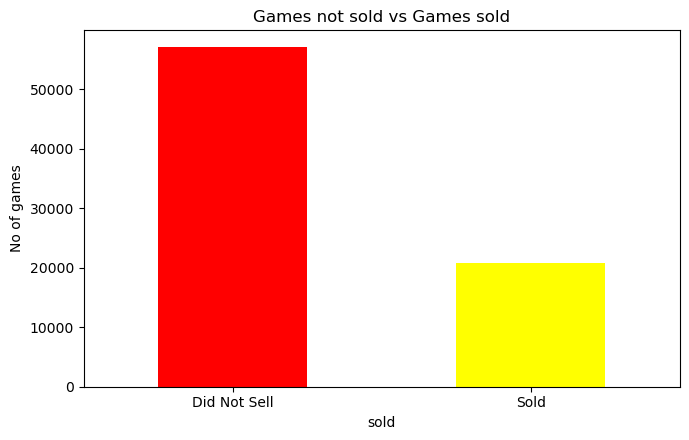

In [10]:
def split_words(text):
    words = []
    for word in text.split(','):
        word = word.strip()
        if word != '' and word not in words:
            words.append(word)
    words.sort()
    return words

paid_game['genre_list'] = paid_game['Genres'].apply(split_words)
paid_game['tag_list'] = paid_game['Tags'].apply(split_words)
paid_game['category_list'] = paid_game['Categories'].apply(split_words)

paid_game['sold'].value_counts().sort_index().plot(kind='bar',color=['red','yellow'],rot=0)
plt.xticks([0,1],['Did Not Sell','Sold'])
plt.ylabel('No of games')
plt.title('Games not sold vs Games sold')
plt.tight_layout()
plt.show()

### Count how often each Category appears, then check the sold-rate for the 15 most common ones

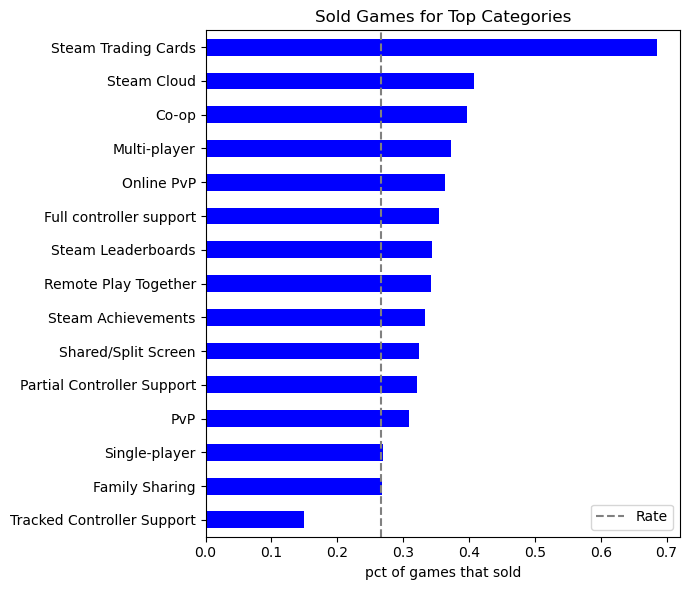

In [11]:
category_counts = {}
for category_list in paid_game['category_list']:
    for category in category_list:
        category_counts[category] = category_counts.get(category, 0) + 1

top_categories = sorted(category_counts, key=category_counts.get, reverse=True)[:15]

sold_by_category ={}
for category in top_categories:
    has_category = paid_game['category_list'].apply(lambda words: category in words)
    sold_by_category[category] = paid_game.loc[has_category, 'sold'].mean()

sold_rates = pd.Series(sold_by_category).sort_values()
plt.figure(figsize=(7, 6))
sold_rates.plot(kind='barh', color='blue')
plt.axvline(paid_game['sold'].mean(), color='grey',linestyle='--',label='Rate')
plt.xlabel("pct of games that sold")
plt.title("Sold Games for Top Categories")
plt.legend()
plt.tight_layout()
plt.show()

### Treating outliers

Price: upper fence 14.6, outliers 7.4%, max 999.98
Achievements: upper fence 52.5, outliers 6.3%, max 9821
num_languages: upper fence 8.5, outliers 13.9%, max 97


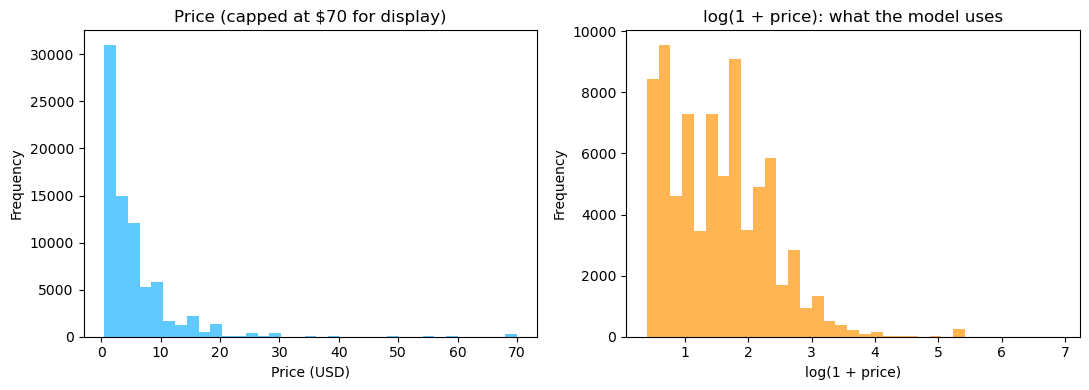

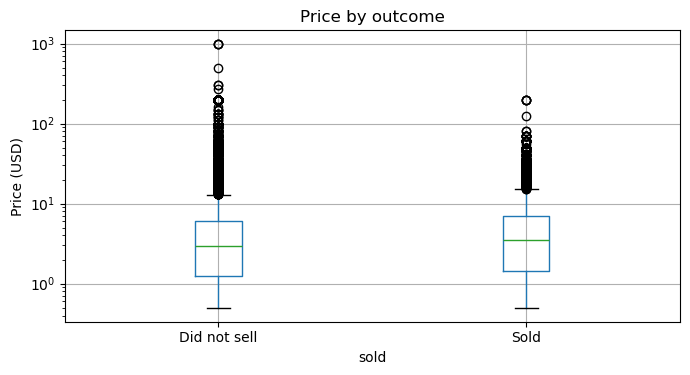

In [12]:
# Outliers using the 1.5 x IQR rule
for column in ['Price', 'Achievements', 'num_languages']:
    q1, q3 = paid_game[column].quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    print(f'{column}: upper fence {upper:.1f}, outliers {(paid_game[column] > upper).mean():.1%}, max {paid_game[column].max()}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
paid_game['Price'].clip(upper=70).plot(kind='hist', bins=35, ax=axes[0], color='#5ec9ff')
axes[0].set_title('Price (capped at $70 for display)')
axes[0].set_xlabel('Price (USD)')
np.log1p(paid_game['Price']).plot(kind='hist', bins=35, ax=axes[1], color='#ffb454')
axes[1].set_title('log(1 + price): what the model uses')
axes[1].set_xlabel('log(1 + price)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
paid_game.boxplot(column='Price', by='sold', ax=ax)
ax.set_yscale('log')
ax.set_xticklabels(['Did not sell', 'Sold'])
ax.set_title('Price by outcome')
ax.set_ylabel('Price (USD)')
plt.suptitle('')
plt.tight_layout()
plt.show()

- 7.4% of prices sit above the `$14.60` fence, with a maximum of `$999.98`. They’re kept rather than removed, because they’re real listings, and tree models split on thresholds, so extreme values can’t distort them. `log1p` reduces the skew for Logistic Regression.

sold                1.000
log_achievements    0.195
num_languages       0.139
required_age        0.120
mac                 0.105
linux               0.069
log_price           0.019
Name: sold, dtype: float64


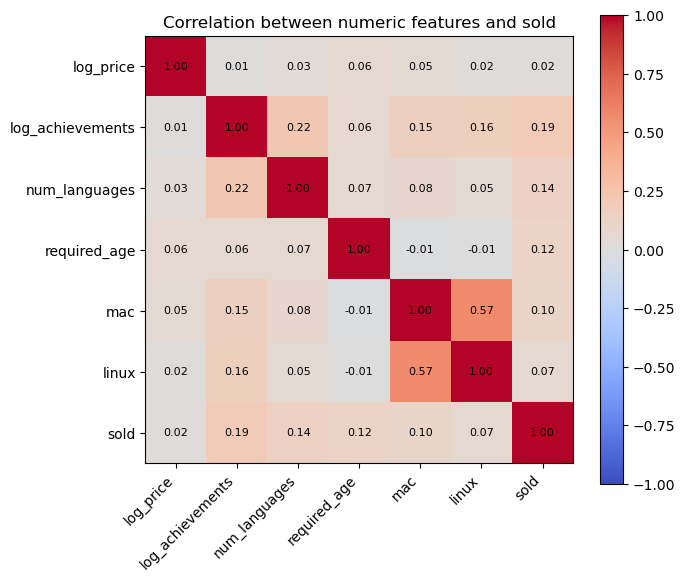

In [13]:
# Correlation of each numeric feature with the outcome
corr_table = pd.DataFrame({
    'log_price': np.log1p(paid_game['Price']), 'log_achievements': np.log1p(paid_game['Achievements']),
    'num_languages': paid_game['num_languages'], 'required_age': paid_game['Required age'],
    'mac': paid_game['Mac'].astype(int), 'linux': paid_game['Linux'].astype(int), 'sold': paid_game['sold']})
corr = corr_table.corr()
print(corr['sold'].sort_values(ascending=False).round(3))

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(image)
ax.set_title('Correlation between numeric features and sold')
plt.tight_layout()
plt.show()

- `Achievements (0.20)` and `languages (0.14)` have the strongest linear link to selling. Games with more achievements and translations sell more often, because both are signs of a bigger, more polished production.
- `Mac` and `Linux` support are related (0.57).
- All of these are weak against sold (below 0.2). No single feature predicts selling on its own. That’s why the model combines 215 features
- `Price`: A straight-line measure averages the rise and the fall into almost nothing (0.02). However, permutation importance ranks price as the model’s most important feature, because trees can learn “higher is better, until it’s too high”. This is evidence that tree models suit this dataset better than Logistic Regression, which can only learn one straight-line direction per feature.
- Limitation: Only numeric features were shown. Genre, tag and store_feature are covered in permutation importance

### Sold rate by languages and release year

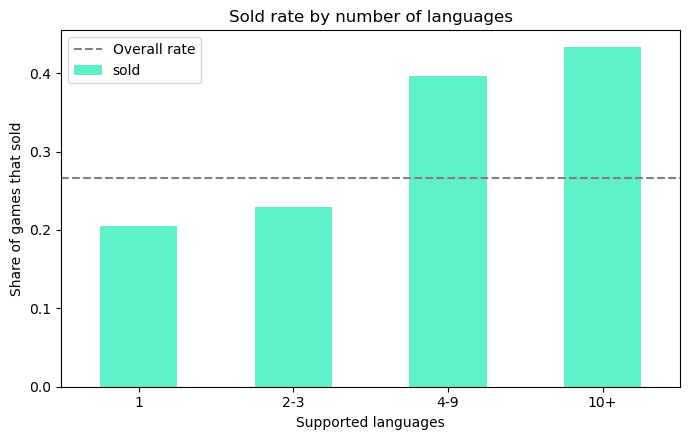

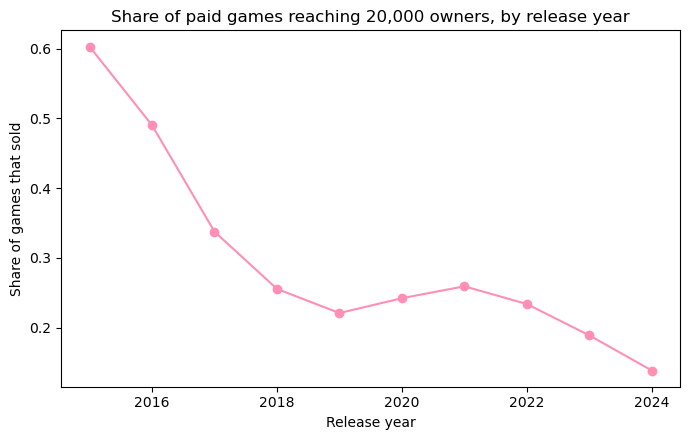

In [14]:
# Sold rate by number of languages
language_band = pd.cut(paid_game['num_languages'], [0, 1, 3, 9, 200], labels=['1', '2-3', '4-9', '10+'])
paid_game.groupby(language_band, observed=True)['sold'].mean().plot(kind='bar', color='#5ef0c9', rot=0)
plt.axhline(paid_game['sold'].mean(), color='grey', linestyle='--', label='Overall rate')
plt.xlabel('Supported languages')
plt.ylabel('Share of games that sold')
plt.title('Sold rate by number of languages')
plt.legend()
plt.tight_layout()
plt.show()

# Sold rate by release year
paid_game.groupby('release_year')['sold'].mean().loc[2015:2024].plot(kind='line', marker='o', color='#ff8fb3')
plt.xlabel('Release year')
plt.ylabel('Share of games that sold')
plt.title('Share of paid games reaching 20,000 owners, by release year')
plt.tight_layout()
plt.show()

- Games in 10+ languages sold 43.3% of the time, against 20.5% for single-language games. The share reaching 20,000 owners fell from 60.3% of 2015 releases to 13.9% of 2024 releases, as releases flooded the store, which shows the market getting harder.

- Why scatterplot was not chosen? With 77,000 games it was too crowded to show anything useful, so the language-band chart above conveys that relationship more clearly.

# Feature Engineering

### Multi-hot encoding for Genre, Tags and Categories
- Genres and Categories are both short, official lists, so both are multi-hot encoded: one column per value, 1 if the game has it and 0 if not. A game can have several, so a row can contain more than one 1. 
- Categories mostly covers settings a developer switches on when publishing, such as Co-op, Full Controller Support or Steam Achievements. These describe the game rather than how it sold, so using them is not data leakage. 
- Leakage fix: Steam Trading Cards: Valve only allows after a game passes a sales threshold. It partly records the outcome, so it is removed 

In [15]:
# Genre
genre_table = pd.get_dummies(paid_game['genre_list'].explode()).groupby(level=0).max()
genre_table = genre_table.reindex(paid_game.index,fill_value=0).astype(int)
print(f"Genre table: {genre_table.shape}")

# Categories
cat_table = pd.get_dummies(paid_game['category_list'].explode()).groupby(level=0).max()
cat_table = cat_table.reindex(paid_game.index,fill_value=0).astype(int)

cat_table = cat_table.drop(columns=['Steam Trading Cards'])
print(f"Category table: {cat_table.shape}")

Genre table: (77764, 33)
Category table: (77764, 55)


### Remove tags that are player opinions ("Great Soundtrack", "Masterpiece", "Underrated", "Overrated", "Funny", "Beautiful", "Emotional"), because those are only added after a game is bought.

In [16]:
tag_counts = {}
for tag_list in paid_game['tag_list']:
    for tag in tag_list:
        tag_counts[tag] = tag_counts.get(tag, 0) + 1

opinion_tags = {'Great Soundtrack', 'Masterpiece', 'Underrated', 'Overrated', 'Funny', 'Beautiful', 'Emotional','Classic', 'Cult Classic', 'Epic', 'Addictive', 'Memes'}

# Sort tags by how common, drop the opinion tags, keep the top 120
sorted_tags = sorted(tag_counts, key=tag_counts.get, reverse=True)
vocabulary = [tag for tag in sorted_tags if tag not in opinion_tags][:120]

# Maps each of the 120 tags to its column number, so building the tag matrix is a quick lookup, and tags outside the top 120 are skipped
tag_to_column = {tag: i for i, tag in enumerate(vocabulary)}

# Build the multi-hot matrix one row at a time
tag_matrix = np.zeros((len(paid_game), len(vocabulary)))
for row_number, tag_list in enumerate(paid_game['tag_list']):
    for tag in tag_list:
        if tag in tag_to_column:
            col_number = tag_to_column[tag]
            tag_matrix[row_number, col_number] = 1

print(f"Tag encoded matrix: {tag_matrix.shape}")

Tag encoded matrix: (77764, 120)


# Numeric features

- Price and achievements are skewed, so `log(1 + x)` compacts them. Language count, required age and platform support stay as they are.

In [17]:
num_features = pd.DataFrame({
    'log_price':        np.log1p(paid_game['Price']),
    'required_age':     pd.to_numeric(paid_game['Required age'], errors='coerce').fillna(0),
    'log_achievements': np.log1p(pd.to_numeric(paid_game['Achievements'], errors='coerce').fillna(0)),
    'num_languages':    paid_game['Supported languages'].fillna('[]').apply(count_languages),
    'windows':          paid_game['Windows'].astype(int),
    'mac':              paid_game['Mac'].astype(int),
    'linux':            paid_game['Linux'].astype(int),
}).reset_index(drop=True)

# Getting the features and target
# Genres, tags, numeric_features and store features
feature_names = (list(genre_table.columns) + vocabulary + list(num_features.columns)
                 + list(cat_table.columns))
X = np.hstack([genre_table.values, tag_matrix, num_features.values, cat_table.values])
y = paid_game['sold'].values

print('Final features matrix:', X.shape)

Final features matrix: (77764, 215)


# Train/test split

- 80% of games train the models and 20% (15,553) are held back for testing. `stratify=y` keeps the same 73/27 split in both.
- The test set is never used for training or tuning: `RandomizedSearchCV` cross-validates within the training set, and the scaler is fitted on the training data only, so no information from the test games leaks in.

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,
                                                 random_state=42,
                                                 stratify=y
)

# Baseline model

### Before proceeding to other models, run it through a baseline that predicts the majority (did not sell) regardless of feature
- This matters because 73% of games did not sell, the model predicts this without having learned anything. If the chosen model can't beat this, then there is no point

In [19]:
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)

baseline_predict = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

print('=== Baseline (always predicts "did not sell") ===')
print(classification_report(y_test, baseline_predict, target_names=['Did not sell', 'Sold'], zero_division=0))
print(f'Baseline ROC AUC: {roc_auc_score(y_test, baseline_proba):.4f}')

fpr_baseline, tpr_baseline, _ = roc_curve(y_test, baseline_proba)

=== Baseline (always predicts "did not sell") ===
              precision    recall  f1-score   support

Did not sell       0.73      1.00      0.85     11404
        Sold       0.00      0.00      0.00      4149

    accuracy                           0.73     15553
   macro avg       0.37      0.50      0.42     15553
weighted avg       0.54      0.73      0.62     15553

Baseline ROC AUC: 0.5000


# Comparing Models

- **Logistic Regression** — a linear model: one weight per feature, combined into a probability. Simple, fast, and easy to explain. Needs its numeric columns scaled first, since price and achievement counts sit on very different scales from the 0/1 genre and tag columns.
- **Random Forest** — many decision trees voting together, able to pick up combinations of features a linear model can't. No scaling needed.
- **Gradient Boosting** — builds trees one at a time, each one correcting the mistakes of the ones before it. Also needs no scaling.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Logistic Regression
numeric_start = len(genre_table.columns) + len(vocabulary)
numeric_end = numeric_start + len(num_features.columns)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[:, numeric_start:numeric_end] = scaler.fit_transform(X_train[:, numeric_start:numeric_end])
X_test_scaled[:, numeric_start:numeric_end] = scaler.transform(X_test[:, numeric_start:numeric_end])

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [21]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=14,
                            random_state=42,
                            n_jobs=-1)

rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]

In [22]:
# Gradient Boosting (untuned)
gradient_untuned = HistGradientBoostingClassifier(random_state=42,
                                                 max_iter=300)
gradient_untuned.fit(X_train, y_train)

proba_gb_untuned = gradient_untuned.predict_proba(X_test)[:, 1]

### Model comparison

In [23]:
comparison_table = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression', 'Random Forest', 'Gradient Boosting (untuned)'],
    'ROC AUC': [
        roc_auc_score(y_test, baseline_proba),
        roc_auc_score(y_test, proba_lr),
        roc_auc_score(y_test, proba_rf),
        roc_auc_score(y_test, proba_gb_untuned),
    ],
}).round(4)

comparison_table

,Model,ROC AUC
0,Baseline,0.5000
1,Logistic Regression,0.7888
2,Random Forest,0.8059
3,Gradient Boosting (untuned),0.8289


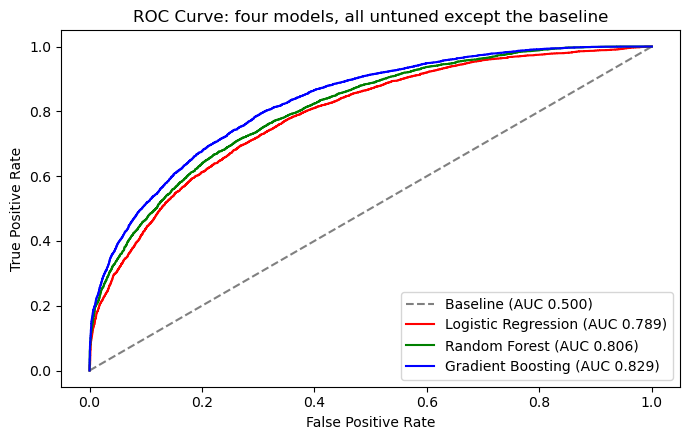

In [24]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
fpr_gbp, tpr_gbp, _ = roc_curve(y_test, proba_gb_untuned)

plt.plot(fpr_baseline, tpr_baseline, color='grey', linestyle='--', label=f'Baseline (AUC {roc_auc_score(y_test, baseline_proba):.3f})')
plt.plot(fpr_lr, tpr_lr, color='red', label=f'Logistic Regression (AUC {roc_auc_score(y_test, proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC {roc_auc_score(y_test, proba_rf):.3f})')
plt.plot(fpr_gbp, tpr_gbp, color='blue', label=f'Gradient Boosting (AUC {roc_auc_score(y_test, proba_gb_untuned):.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: four models, all untuned except the baseline')
plt.legend()
plt.tight_layout()
plt.show()

 - Features carry significant impact. The gap suggests combinations of features matter (for example, low price **and** many languages **and** co-op support together), which trees can capture and a linear model can't. The final model tunes Gradient Boosting specifically, since it already leads before tuning even starts

# Hyperparameter Tuning

- A model has two kinds of numbers: **learned values**, which training works out from the data (each tree's split points and leaf values), and **hyperparameters**, settings chosen *before* training that control how it learns. Rather than accept scikit-learn's default settings, a small grid of Gradient Boosting settings is searched with `RandomizedSearchCV`, trying a random sample of combinations and cross-validates each one (splitting the training data itself into folds, so the test set stays untouched throughout).

| Setting | What it controls | Values tried | Default |
|---|---|---|---|
| `learning_rate` | How big a step each new tree takes when correcting the previous ones. Smaller is more cautious, but needs more trees | 0.03, 0.05, 0.08 | 0.1 |
| `max_leaf_nodes` | How many final groups (leaves) each tree can split the games into, i.e. how detailed each tree can be | 15, 31, 63 | 31 |
| `min_samples_leaf` | The fewest games a leaf may contain, so no rule is based on a handful of games | 10, 20, 40 | 20 |
| `l2_regularization` | A penalty that shrinks each leaf's correction, mostly for leaves based on few games | 0, 0.5, 1.0 | 0 |

### Three values for each settings are taken for search (3 x 3 x 3 x 3) -> 81 combinations

In [25]:
params = {
    'learning_rate': [0.03,0.05,0.08],
    'max_leaf_nodes': [15,31,63],
    'l2_regularization': [0,0.5,1.0],
    'min_samples_leaf': [10,20,40],
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42,max_iter=300),
    params,
    n_iter=4,
    scoring='roc_auc',
    cv=2,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train,y_train)

print(f"Best setting: {search.best_params_}")
gb_tuned = search.best_estimator_

Best setting: {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'learning_rate': 0.08, 'l2_regularization': 0}


### Gradient Boosting (tuned) Evaluation

In [26]:
probability = gb_tuned.predict_proba(X_test)[:, 1]
predictions = (probability >= 0.5).astype(int)

print(classification_report(y_test, predictions, target_names=['Did not sell', 'Sold']))

print(f'Gradient Boosting ROC AUC: {roc_auc_score(y_test, probability):.4f}')

              precision    recall  f1-score   support

Did not sell       0.82      0.94      0.87     11404
        Sold       0.72      0.42      0.53      4149

    accuracy                           0.80     15553
   macro avg       0.77      0.68      0.70     15553
weighted avg       0.79      0.80      0.78     15553

Gradient Boosting ROC AUC: 0.8296


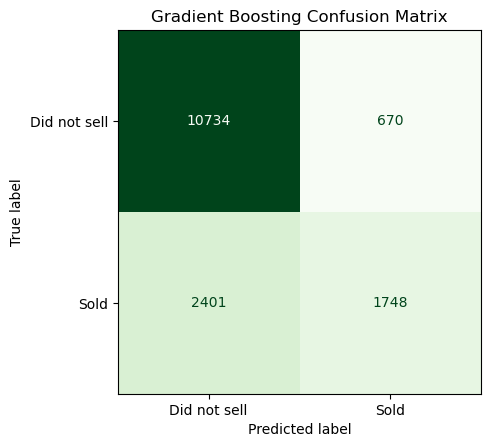

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, display_labels=['Did not sell', 'Sold'],
    cmap='Greens', values_format='d', ax=ax, colorbar=False
)
plt.title('Gradient Boosting Confusion Matrix')
plt.tight_layout()
plt.show()

- The model looked at 15,553 test games it had never seen. For each one it guessed “Sold” or “Did not sell”, and then the guess was checked against what actually happened. The confusion matrix counts how those guesses turned out. The diagonal from top-left to bottom-right is where the model was right. The other two boxes are its mistakes
- 10,734: true negatives. The game flopped and the model said it would. These are correct rejections.
- 1,748: true positives. The game reached 20,000 owners and the model said it would. These are the hits it caught.
- 670: false positives (false alarms). The model said “this will sell”, but it didn’t. For a developer this is the dangerous mistake, because they’d be told to go ahead with a game that then flops.
- 2,401: false negatives (missed hits). The game did sell, but the model said it wouldn’t. The model was too pessimistic about these games.
- The model is cautious: when it predicts "Sold", it is right 72% of the time (1,748 of 2,418), but it misses more than half of the real hits. This comes from the class imbalance (73% did not sell) and the 0.5 cutoff, since many hits score above the 26.7% average but below 50%. Lowering the cutoff would catch more hits at the cost of more false alarms. The baseline, by comparison, scores 73% accuracy but catches zero hits

### Why Gradient Boosting was chosen:
- **Gradient Boosting led before any tuning**, so it wasn't chosen because tuning happened to favour it.
- **Against the baseline**, the tuned model catches 42% of games that actually sold, with 72% precision,
  where the baseline catches none.

### HistGradientBoostingClassifier does not expose feature_importances_ the way Random Forest does, so permutation importance is used instead

- Mix up one feature's values between games and see how much worse the model gets. The bigger the drop, the more the model relies on that feature.
- Think of it like removing one ingredient from a recipe and tasting the difference. If the dish gets much worse, that ingredient mattered.

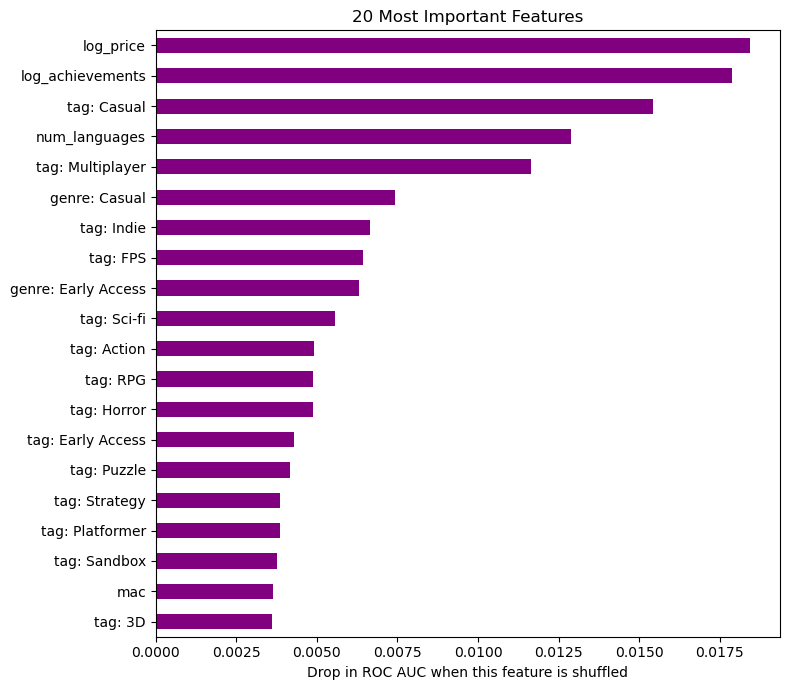

In [28]:
from sklearn.inspection import permutation_importance

# n_repeats = 2, because one can be counted as lucky/unlucky
# size=2000 - 2000 games are chosen
# replace - no game get picks twice
sample_positions = np.random.default_rng(42).choice(len(X_test), size=2000, replace=False)
result = permutation_importance(
    gb_tuned, X_test[sample_positions], y_test[sample_positions],
    n_repeats=2, random_state=42, scoring='roc_auc', n_jobs=-1
)

# Labels that show where each feature comes from, so "Casual" genre and "Casual" tag are distinguishable
important_labels = ([f'genre: {name}' for name in genre_table.columns] + [f'tag: {name}' for name in vocabulary]
                     + list(num_features.columns) + [f'feature: {name}' for name in cat_table.columns])
important = pd.Series(result.importances_mean, index=important_labels)

top_important = important.sort_values(ascending=False).head(20)
plt.figure(figsize=(8,7))
top_important[::-1].plot(kind='barh', color='purple')
plt.title('20 Most Important Features')
plt.xlabel('Drop in ROC AUC when this feature is shuffled')
plt.tight_layout()
plt.show()

- The top five are `log_price`, `log_achievements`, `tag: Casual`, `num_languages` and `tag: Multiplayer`. Price and achievements each lower ROC AUC by about 0.018 when shuffled.
- Price ranks first even though its correlation with selling was almost zero (0.02). This confirms its effect isn't a straight line, which a tree model can learn and Logistic Regression can't.
- Achievements and languages rank highly, matching the correlation section: both are signs of a bigger, more polished production.
- The biggest single drop is under 0.02, so no one feature carries the model on its own. Its accuracy comes from combining many features, which matches what the correlation section found.

# Predicting a New Game

- Each source (genres, tags, categories) is written to its own fixed position in the input vector. Several words appear in more than one source — "Action" is both a Genre and a Tag, "Co-op" is both a Tag and a Category — so a single shared name-to-value dictionary would let one source silently overwrite another. Keeping each source in its own slice of the vector avoids that entirely. The function is assisted with AI for notebook showcase purposes

In [29]:
genre_position = {name: i for i, name in enumerate(genre_table.columns)}
tag_position = {name: i for i, name in enumerate(vocabulary)}
category_position = {name: i for i, name in enumerate(cat_table.columns)}

tag_offset = len(genre_table.columns)
numeric_offset = tag_offset + len(vocabulary)
category_offset = numeric_offset + len(num_features.columns)


def predict_sale_chance(genres, tags, categories, price, required_age=0, achievements=0,
                        languages=1, windows=1, mac=0, linux=0):
    vector = [0] * len(feature_names)
    unknown_values = []

    for genre in genres:
        if genre in genre_position:
            vector[genre_position[genre]] = 1
        else:
            unknown_values.append(genre)

    for tag in tags:
        if tag in tag_position:
            vector[tag_offset + tag_position[tag]] = 1
        else:
            unknown_values.append(tag)

    for category in categories:
        if category in category_position:
            vector[category_offset + category_position[category]] = 1
        else:
            unknown_values.append(category)

    if unknown_values:
        print('Ignoring values the model does not know:', unknown_values)

    # Numeric columns, in the exact order they were built in section 5:
    # log_price, required_age, log_achievements, num_languages, windows, mac, linux
    vector[numeric_offset + 0] = np.log1p(price)
    vector[numeric_offset + 1] = required_age
    vector[numeric_offset + 2] = np.log1p(achievements)
    vector[numeric_offset + 3] = languages
    vector[numeric_offset + 4] = windows
    vector[numeric_offset + 5] = mac
    vector[numeric_offset + 6] = linux

    input_row = np.array([vector])
    return round(float(gb_tuned.predict_proba(input_row)[0, 1]), 3)


base_rate = y.mean()
print(f'Overall share of paid games that sold: {base_rate:.1%}')
print()

# Use case 1
chance = predict_sale_chance(
    ['Action', 'Indie'], ['Multiplayer', 'Co-op', 'Open World'],
    ['Co-op', 'Online Co-op', 'Steam Achievements'],
    price=15, achievements=30, languages=6, mac=1, linux=1
)
print(f'Action/Indie co-op game, $15, 6 languages, co-op categories:  {chance:.1%}')

# Use case 2
chance = predict_sale_chance(
    ['Casual'], ['Puzzle', '2D'], ['Single-player'],
    price=3, achievements=5, languages=1
)
print(f'Small $3 casual puzzle game, English only, single-player:     {chance:.1%}')

Overall share of paid games that sold: 26.7%

Action/Indie co-op game, $15, 6 languages, co-op categories:  78.2%
Small $3 casual puzzle game, English only, single-player:     7.7%


# Summary Report

- Gradient Boosting came out on top, beating the baseline and both models, LogisticRegression and RandomForest
- Three problems were found across previous testings: leaking features, duplicate removed by name instead of ID and recent games that did not have time to sell
- At the 0.5 cutoff, 94% recall on "Did not sell" but 42% on "Sold". A lower cutoff would catch more hits at the cost of false alarms

## Limitations
- "Estimated owners" is Steam's own estimate, not a confirmed sales figure, and 20,000 is a bucket boundary, not a universal definition of commercial success.
- Free-to-play games are excluded.
- Marketing, timing, and word of mouth are not in the data at all, and likely matter more than anything measured here.
- My search only tried 4 combinations (8 model fits) to keep processing reasonable; a wider search might find slightly better settings.

## Future Improvements
- A wider parameter search, and run them separately
- Adding release year to observe how the market changes overtime
- Predicting a better outcome (owner number) instead of a yes/no

# Exporting the model

- **`model/model.joblib`** and **`model/model_info.json`**: the trained model and its column lists. The prediction API (`api/predict.py`) loads these on Vercel and runs the real scikit-learn model.
- The same trees as JSON inside `index.html`: a built-in copy the page uses when the API isn't reachable

In [30]:
import json
import os
import re
import joblib
import sklearn

site_folder = 'steamscope-live'
os.makedirs(os.path.join(site_folder, 'model'), exist_ok=True)

# 1) The real scikit-learn model, for the prediction API
joblib.dump(gb_tuned, os.path.join(site_folder, 'model', 'model.joblib'), compress=3)

model_info = {
    'model_name': 'Gradient Boosting (v7)',
    'roc_auc': round(float(roc_auc_score(y_test, gb_tuned.predict_proba(X_test)[:, 1])), 4),
    'genres': list(genre_table.columns),
    'tags': vocabulary,
    'categories': list(cat_table.columns),
    'numeric': list(num_features.columns),
    'base_rate': float(y.mean()),
    'sklearn_version': sklearn.__version__,
}
with open(os.path.join(site_folder, 'model', 'model_info.json'), 'w') as f:
    json.dump(model_info, f)

# 2) The same trees as plain lists, for the page's built-in copy.
# Each node becomes [feature, threshold, left child, right child, leaf value]; a feature of -1 marks a leaf.
def tree_to_list(tree):
    nodes = []
    for node in tree.nodes:
        if node['is_leaf']:
            nodes.append([-1, 0, -1, -1, float(node['value'])])
        else:
            nodes.append([int(node['feature_idx']), float(node['num_threshold']), int(node['left']), int(node['right']), 0])
    return nodes

trees_json = {
    'baseline': float(gb_tuned._baseline_prediction.squeeze()),   # starting score: log-odds of the base rate
    'trees': [tree_to_list(iteration[0]) for iteration in gb_tuned._predictors],
}

# Replace the two lines in index.html that hold the model and its column lists
page_path = os.path.join(site_folder, 'index.html')
with open(page_path, encoding='utf-8') as f:
    page = f.read()

new_lines = ('const MODEL = ' + json.dumps(trees_json, separators=(',', ':')) + ';\n'
             + 'const MG = ' + json.dumps(model_info['genres'], separators=(',', ':'))
             + ', MT = ' + json.dumps(model_info['tags'], separators=(',', ':'))
             + ', MC = ' + json.dumps(model_info['categories'], separators=(',', ':'))
             + ', BASE_RATE = ' + json.dumps(model_info['base_rate']) + ';\n')
page, replaced = re.subn(r'const MODEL = .*?;\nconst MG = .*?;\n', lambda match: new_lines, page, count=1, flags=re.S)
if replaced != 1:
    raise ValueError('Could not find the model lines in index.html')

with open(page_path, 'w', encoding='utf-8') as f:
    f.write(page)

print(f"Exported {len(trees_json['trees'])} trees, ROC AUC {model_info['roc_auc']}")
print(f"requirements.txt should say: scikit-learn=={sklearn.__version__}")


Exported 242 trees, ROC AUC 0.8296
requirements.txt should say: scikit-learn==1.7.2


# Saving cleaned dataset

In [31]:
genre_part = genre_table.add_prefix('genre_').reset_index(drop=True)
tag_part = pd.DataFrame(tag_matrix, columns=vocabulary).astype(int).add_prefix('tag_')
category_part = cat_table.add_prefix('feature_').reset_index(drop=True)

cleaned_dataset = pd.concat([
    paid_game[['AppID', 'Name', 'release_year', 'Price', 'sold']].reset_index(drop=True),
    genre_part,
    tag_part,
    num_features,
    category_part,
], axis=1)

cleaned_dataset.to_csv('games_data_cleaned.csv', index=False)
print('Saved games_data_cleaned.csv:', cleaned_dataset.shape)
#cleaned_dataset.head()

Saved games_data_cleaned.csv: (77764, 220)
